### [Forecasting Solar Irradiance with Regime-Aware LSTM](https://medium.com/@kyle-t-jones/forecasting-solar-irradiance-with-regime-aware-lstm-29830cbe220e)

Utilities and grid operators rely on accurate solar forecasts to manage generation, maintain reliability, and avoid unnecessary curtailment. As solar penetration increases, errors in irradiance forecasting can translate directly into balancing costs, reserve overcommitment, or missed financial targets.

> SolarAnywhere Time Series



#### 1. Load and preprocess SolarAnywhere data


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv("/content/Bellevue_SolarAnywhere_TimeSeries.csv", encoding="cp1252", header=1)
df["time"] = pd.to_datetime(df["ObservationTime(LST)"])
df = df.set_index("time")

df = df[[
    "Global Horizontal Irradiance (GHI) W/m2",
    "AmbientTemperature (deg C)",
    "Relative Humidity (%)",
    "Wind Speed (m/s)"
]]

df.columns = ["GHI", "Temp", "Humidity", "Wind"]
df = df.resample("D").mean().dropna()
df["Regime"] = pd.cut(df.index.dayofyear, bins=4, labels=False)

df.head()

,GHI,Temp,Humidity,Wind,Regime
time,,,,,
2023-01-01,27.260870,5.652174,92.826087,0.869565,0
2023-01-02,53.833333,3.916667,73.791667,2.333333,0
2023-01-03,41.708333,5.083333,78.875000,2.041667,0
2023-01-04,30.708333,6.375000,61.250000,3.500000,0
2023-01-05,19.583333,11.250000,53.208333,4.791667,0


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 366 entries, 2023-01-01 to 2024-01-01
Freq: D
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   GHI       366 non-null    float64
 1   Temp      366 non-null    float64
 2   Humidity  366 non-null    float64
 3   Wind      366 non-null    float64
 4   Regime    366 non-null    int64  
dtypes: float64(4), int64(1)
memory usage: 17.2 KB


In [4]:
df.describe()

,GHI,Temp,Humidity,Wind,Regime
count,366.000000,366.000000,366.000000,366.000000,366.000000
mean,145.536232,11.705220,75.833427,2.302467,1.491803
std,110.268429,5.735865,9.824092,0.997264,1.121979
min,0.000000,-1.375000,41.375000,0.541667,0.000000
25%,51.864583,6.885417,69.104167,1.583333,0.000000
50%,109.979167,11.145833,76.625000,2.104167,1.000000
75%,238.614583,16.875000,83.541667,2.791667,2.000000
max,362.000000,23.958333,94.125000,6.583333,3.000000


In [5]:
from sklearn.preprocessing import MinMaxScaler

features = ["GHI", "Temp", "Humidity", "Wind"]
scaler = MinMaxScaler()
df[features] = scaler.fit_transform(df[features])

#### 2. Define dataset

In [6]:
import torch
from torch.utils.data import Dataset, DataLoader

class TimeSeriesDataset(Dataset):
    def __init__(self, df, seq_len=30):
        self.X, self.y, self.r = [], [], []
        for i in range(len(df) - seq_len):
            self.X.append(df.iloc[i:i+seq_len][features].values)
            self.y.append(df.iloc[i+seq_len]["GHI"])
            self.r.append(df.iloc[i+seq_len]["Regime"])
        self.X = torch.tensor(self.X, dtype=torch.float32)
        self.y = torch.tensor(self.y, dtype=torch.float32).unsqueeze(1)
        self.r = torch.tensor(self.r, dtype=torch.long)
    def __len__(self):
        return len(self.X)
    def __getitem__(self, idx):
        return self.X[idx], self.r[idx], self.y[idx]
dataset = TimeSeriesDataset(df)
train_loader = DataLoader(dataset, batch_size=32, shuffle=True)

#### 3. Define models

In [7]:
import torch.nn as nn
class VanillaLSTM(nn.Module):
    def __init__(self, input_dim=4, hidden_dim=64):
        super().__init__()
        self.lstm = nn.LSTM(input_dim, hidden_dim, batch_first=True)
        self.fc = nn.Linear(hidden_dim, 1)
    def forward(self, x, *_):
        out, _ = self.lstm(x)
        return self.fc(out[:, -1, :])
class RegimeLSTM(nn.Module):
    def __init__(self, input_dim=4, hidden_dim=64, num_regimes=4):
        super().__init__()
        self.embedding = nn.Embedding(num_regimes, 4)
        self.lstm = nn.LSTM(input_dim + 4, hidden_dim, batch_first=True)
        self.fc = nn.Linear(hidden_dim, 1)
    def forward(self, x, regime_id):
        regime_embed = self.embedding(regime_id)
        regime_expanded = regime_embed.unsqueeze(1).expand(-1, x.size(1), -1)
        x_augmented = torch.cat([x, regime_expanded], dim=2)
        out, _ = self.lstm(x_augmented)
        return self.fc(out[:, -1, :])

#### 4. Train

In [8]:
def train_model(model, loader, epochs=10):
    optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
    loss_fn = nn.MSELoss()
    model.train()
    for epoch in range(epochs):
        total_loss = 0
        for x, r, y in loader:
            optimizer.zero_grad()
            pred = model(x, r)
            loss = loss_fn(pred, y)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
        print(f"Epoch {epoch+1}: Loss = {total_loss / len(loader):.4f}")
vanilla = VanillaLSTM()
train_model(vanilla, train_loader)
regime_model = RegimeLSTM()
train_model(regime_model, train_loader)

Epoch 1: Loss = 0.1860
Epoch 2: Loss = 0.0716
Epoch 3: Loss = 0.0609
Epoch 4: Loss = 0.0495
Epoch 5: Loss = 0.0412
Epoch 6: Loss = 0.0405
Epoch 7: Loss = 0.0433
Epoch 8: Loss = 0.0395
Epoch 9: Loss = 0.0382
Epoch 10: Loss = 0.0389
Epoch 1: Loss = 0.1570
Epoch 2: Loss = 0.0639
Epoch 3: Loss = 0.0472
Epoch 4: Loss = 0.0466
Epoch 5: Loss = 0.0420
Epoch 6: Loss = 0.0414
Epoch 7: Loss = 0.0379
Epoch 8: Loss = 0.0361
Epoch 9: Loss = 0.0373
Epoch 10: Loss = 0.0358


 #### 5. Evaluate

In [9]:
from sklearn.metrics import mean_squared_error

vanilla.eval()
regime_model.eval()
y_true, y_vanilla, y_regime = [], [], []

with torch.no_grad():
    for x, r, y in train_loader:
        y_true.append(y)
        y_vanilla.append(vanilla(x))
        y_regime.append(regime_model(x, r))

y_true = torch.cat(y_true).numpy()
y_vanilla = torch.cat(y_vanilla).numpy()
y_regime = torch.cat(y_regime).numpy()

print(f"Vanilla LSTM MSE: {mean_squared_error(y_true, y_vanilla):.4f}")
print(f"Regime-Aware LSTM MSE: {mean_squared_error(y_true, y_regime):.4f}")

Vanilla LSTM MSE: 0.0367
Regime-Aware LSTM MSE: 0.0353


#### 6. Plot

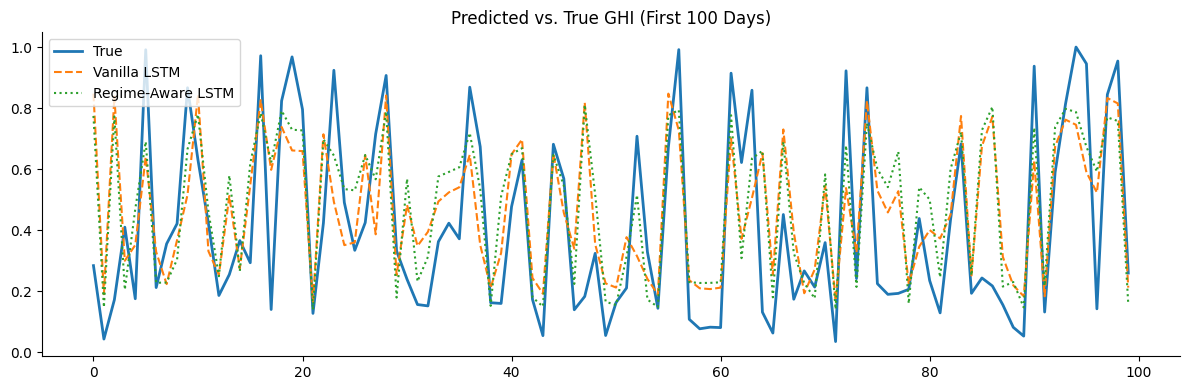

In [10]:
import matplotlib.pyplot as plt
plt.figure(figsize=(12, 4))
plt.plot(y_true[:100], label="True", linewidth=2)
plt.plot(y_vanilla[:100], label="Vanilla LSTM", linestyle="--")
plt.plot(y_regime[:100], label="Regime-Aware LSTM", linestyle=":")
plt.title("Predicted vs. True GHI (First 100 Days)")

ax = plt.gca()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.legend()
plt.tight_layout()
plt.savefig("ghi_lstm_comparison.png")
plt.show()